In [1]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
from Utils.OfficeCaltechDecafLoader import OfficeCaltechDecafDataset
import sklearn
from ot_utils import *
from Utils.joint_OT_mapping_linear_classreg import free_support_sinkhorn_barycenter, MappingTransport
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [2]:
dataset = OfficeCaltechDecafDataset(data_path='/Users/balazsmorvay/PycharmProjects/fmri_classifier/Data/Office-Caltech')
X = dataset.X
y = dataset.y
m = dataset.m
domains = dataset.domains
domain_names = dataset.domain_names

In [3]:

X_all = []
y_all = []
for i, domain in enumerate(domains):
    domain_indices = np.where(m == domain)
    X_all.append(torch.tensor(X[domain_indices], dtype=torch.float32, device=device))
    y_all.append(torch.tensor(y[domain_indices], dtype=torch.int, device=device))

In [4]:
X_trains = []
X_tests = []
y_trains = []
y_tests = []

for i in range(len(X_all)):
    X_i = X_all[i].cpu()
    y_i = y_all[i].cpu()
    X_i_train, X_i_test, y_i_train, y_i_test = sklearn.model_selection.train_test_split(X_i, y_i, train_size=0.3, shuffle=True, stratify=y_i, random_state=42)
    X_trains.append(X_i_train.to(device))
    X_tests.append(X_i_test.to(device))
    y_trains.append(y_i_train.to('cpu'))
    y_tests.append(y_i_test.to('cpu'))


In [5]:
xs = X_trains[1]
xt = X_trains[0]
ys = y_trains[1]
yt = y_trains[0]
M = dist_classreg(xs, xt, ys, yt, device=device)

a = torch.tensor([1.0 / xs.shape[0]] * xs.shape[0], dtype=torch.float32, device=device)
b = torch.tensor([1.0 / xt.shape[0]] * xt.shape[0], dtype=torch.float32, device=device)

P = ot.sinkhorn(a=a, b=b, reg=5e-1, M=M, method='sinkhorn_log')

/Users/balazsmorvay/anaconda3/envs/fmri_classifier/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:748: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn("Sinkhorn did not converge. You might want to "


In [6]:
def classifier1nn(X_train, y_train, X_test):
    # Compute pairwise distances
    distances = np.linalg.norm(X_test[:, np.newaxis, :] - X_train[np.newaxis, :, :], axis=2)

    closest_indices = np.argmin(distances, axis=1)

    return y_train[closest_indices]

performance on the test set

In [7]:
y_pred = classifier1nn(X_trains[0].cpu(), y_trains[0].cpu(), X_tests[0].cpu())
torch.sum(y_pred == y_tests[0].cpu()) / len(y_pred)

tensor(0.9227)

performance in out of distribution test set

In [8]:
y_pred = classifier1nn(X_trains[0].cpu(), y_trains[0].cpu(), X_tests[1].cpu())
torch.sum(y_pred == y_tests[1].cpu()) / len(y_pred)

tensor(0.5380)

compute barycenter

In [9]:
n_train = 0
for i in range(len(X_trains)):
    n_train += X_trains[i].shape[0]
a1, a2, a3, a4 = ot.unif(len(X_trains[0])), ot.unif(len(X_trains[1])), ot.unif(len(X_trains[2])), ot.unif(len(X_trains[3]))
weights = [torch.tensor(a1, dtype=torch.float32, device=device), torch.tensor(a2, dtype=torch.float32, device=device), torch.tensor(a3, dtype=torch.float32, device=device), torch.tensor(a4, dtype=torch.float32, device=device)]
recompute = True

barycenter = free_support_sinkhorn_barycenter(
        measures_locations=X_trains,
        measures_weights=weights,
        measure_labels=y_trains,
        bary_labels=torch.concatenate(y_trains),
        reg=1e-1,
        numItermax=10,
        numInnerItermax=3000,
        verbose=True,
        X_init=torch.rand(size=(n_train, 4096), device=device),
        b=torch.ones(size=(n_train,), device=device) / n_train,
        method='sinkhorn_log',
        stopThr=0.0001
    )

iteration %d, displacement_square_norm=%f
 0 tensor(32642322., device='mps:0')
iteration %d, displacement_square_norm=%f
 1 tensor(823951.5000, device='mps:0')
iteration %d, displacement_square_norm=%f
 2 tensor(154100.8125, device='mps:0')
iteration %d, displacement_square_norm=%f
 3 tensor(24330.6250, device='mps:0')
iteration %d, displacement_square_norm=%f
 4 tensor(6837.3291, device='mps:0')
iteration %d, displacement_square_norm=%f
 5 tensor(0., device='mps:0')


compute coupling matrix

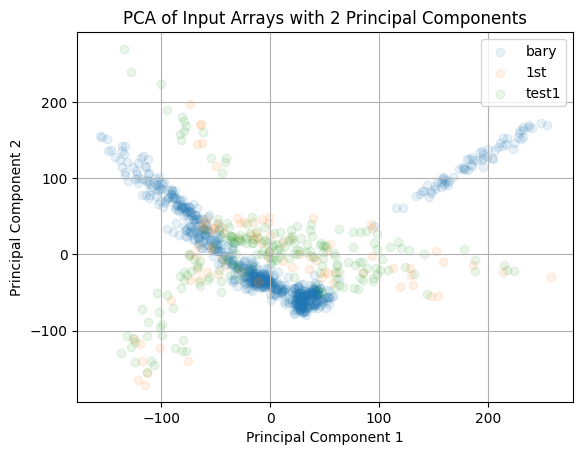

In [10]:
from Utils.visualization_utils import plot_pca_for_arrays, visualize_barycenter_diracs
plot_pca_for_arrays(arrays=[barycenter.cpu(), X_trains[0].cpu(), X_tests[0].cpu()], n_components=2, labels=['bary', '1st', 'test1'])
plt.show()

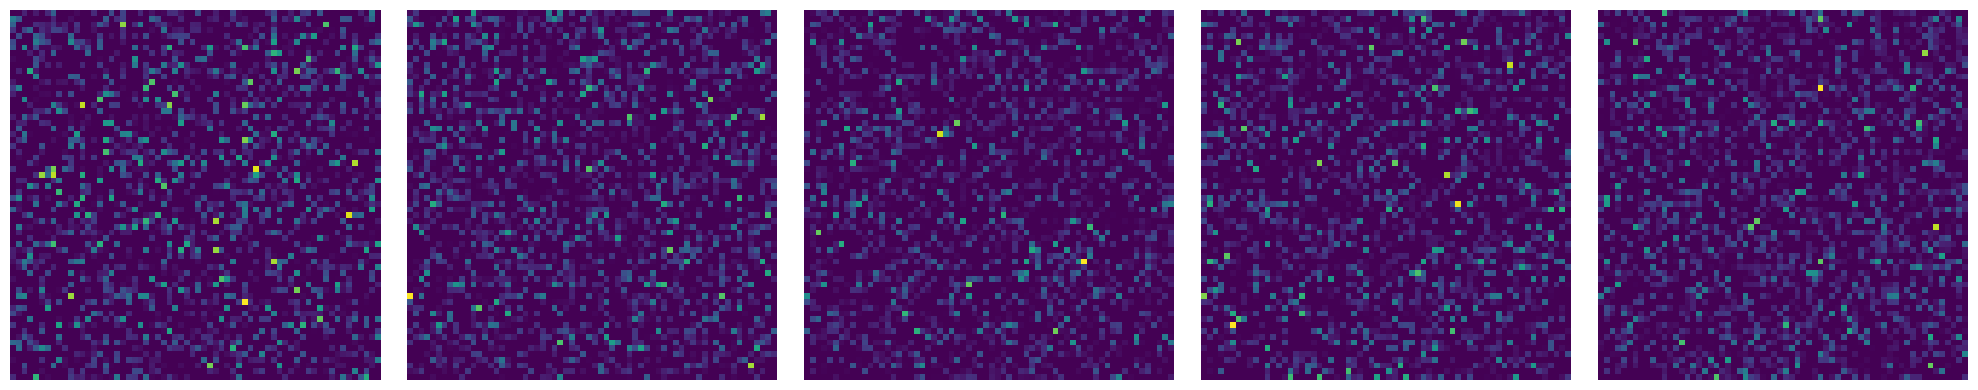

In [11]:
visualize_barycenter_diracs(barycenter.cpu(), 5, 42)
plt.show()

/Users/balazsmorvay/anaconda3/envs/fmri_classifier/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:748: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn("Sinkhorn did not converge. You might want to "


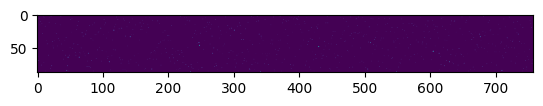

In [12]:
xs = X_trains[0]
xt = barycenter
ys = y_trains[0]
y_bari = torch.concatenate(y_trains).cpu()
yt = y_bari.to(device)
M = dist_classreg(xs, xt, ys, yt, device=device)

a = torch.tensor([1.0 / xs.shape[0]] * xs.shape[0], dtype=torch.float32, device=device)
b = torch.tensor([1.0 / xt.shape[0]] * xt.shape[0], dtype=torch.float32, device=device)

P = ot.sinkhorn(a=a, b=b, reg=1e-1, M=M, method='sinkhorn_log', numItermax=1000)

plt.imshow(P.cpu())

compute performance on the barycenter, using barycentric mapping

In [13]:
transp_xs = barycentric_mapping(xs, xt, X_tests[3], P)

y_pred = classifier1nn(xt.cpu(), yt.cpu(), X_tests[3].cpu())
torch.sum(y_pred == y_tests[3].cpu()) / len(y_pred)

out of sample mapping


tensor(0.8551)

In [14]:
from Utils.SVM_utils import train_svm, test_svm

model = train_svm(xt.cpu(), y_bari.cpu(), kernel='rbf', C=1.0)
model.fit_status_ == 0

[LibSVM]*
optimization finished, #iter = 88
obj = -3.386748, rho = 0.183015
nSV = 46, nBSV = 1
*
optimization finished, #iter = 95
obj = -3.845233, rho = 0.215804
nSV = 46, nBSV = 0
*
optimization finished, #iter = 117
obj = -6.451565, rho = 0.101074
nSV = 55, nBSV = 1
*
optimization finished, #iter = 86
obj = -3.543142, rho = 0.246835
nSV = 44, nBSV = 0
*
optimization finished, #iter = 98
obj = -4.610382, rho = 0.198244
nSV = 44, nBSV = 0
*
optimization finished, #iter = 98
obj = -4.872009, rho = 0.029435
nSV = 47, nBSV = 0
*
optimization finished, #iter = 99
obj = -5.593769, rho = 0.077721
nSV = 46, nBSV = 1
*
optimization finished, #iter = 99
obj = -4.215427, rho = 0.025181
nSV = 48, nBSV = 0
*
optimization finished, #iter = 118
obj = -5.712202, rho = 0.164849
nSV = 51, nBSV = 0
*
optimization finished, #iter = 93
obj = -3.410811, rho = 0.002484
nSV = 46, nBSV = 0
*
optimization finished, #iter = 105
obj = -3.834731, rho = -0.068331
nSV = 56, nBSV = 1
*
optimization finished, #iter 

True

out of sample mapping
out of sample mapping
out of sample mapping
out of sample mapping
{'accuracy': 0.9710144927536232, 'recall': array([1.        , 1.        , 0.90909091, 1.        , 1.        ,
       1.        , 0.96666667, 0.85714286, 1.        , 1.        ]), 'precision': array([1.        , 1.        , 1.        , 0.9047619 , 0.9047619 ,
       0.95454545, 1.        , 1.        , 1.        , 0.95454545]), 'fscore': array([1.        , 1.        , 0.95238095, 0.95      , 0.95      ,
       0.97674419, 0.98305085, 0.92307692, 1.        , 0.97674419])}


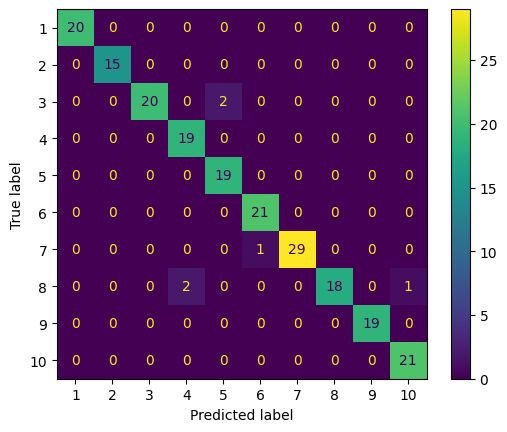

In [15]:
transp_xs_1 = barycentric_mapping(xs, xt, X_tests[0], P)
transp_xs_2 = barycentric_mapping(xs, xt, X_tests[1], P)
transp_xs_3 = barycentric_mapping(xs, xt, X_tests[2], P)
transp_xs_4 = barycentric_mapping(xs, xt, X_tests[3], P)

metrics, disp = test_svm(model, transp_xs_1.cpu(), y_tests[0].cpu())
disp.plot()
print(metrics)